In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

rng = np.random.default_rng(7)
plt.rcParams["figure.figsize"] = (7, 4)
backend_sim = AerSimulator()

In [ ]:
encoding_table = pd.DataFrame({
    "Bit": [0, 1, 0, 1],
    "Basis": ["Z (0)", "Z (0)", "X (1)", "X (1)"],
    "State": ["|0⟩", "|1⟩", "|+⟩", "|−⟩"],
    "Gates Applied": ["none", "X", "H", "X, H"]
})
encoding_table

,Bit,Basis,State,Gates Applied
0,0,Z (0),|0⟩,none
1,1,Z (0),|1⟩,X
2,0,X (1),|+⟩,H
3,1,X (1),|−⟩,"X, H"


In [ ]:
def generate_random_bits_and_bases(n, seed=None):
    rng_local = np.random.default_rng(seed)
    bits = rng_local.integers(0, 2, n)
    bases = rng_local.integers(0, 2, n)
    return bits, bases

N = 30
abits, abase = generate_random_bits_and_bases(N, seed=1)

print("Alice's bits: ", abits)
print("Alice's bases:", abase, " (0=Z, 1=X)")

Alice's bits:  [0 1 1 1 0 0 1 1 0 0 1 0 0 1 0 0 1 1 0 0 1 1 1 1 1 0 0 1 0 0]
Alice's bases: [0 0 1 0 0 0 1 0 1 0 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 0 1 0 0 1]  (0=Z, 1=X)


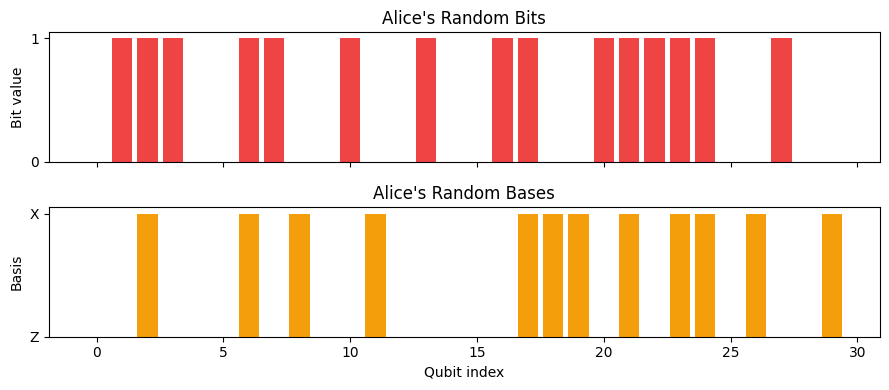

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(9, 4), sharex=True)

axes[0].bar(range(N), abits, color=['#3b82f6' if b == 0 else '#ef4444' for b in abits])
axes[0].set_ylabel("Bit value")
axes[0].set_yticks([0, 1])
axes[0].set_title("Alice's Random Bits")

axes[1].bar(range(N), abase, color=['#10b981' if b == 0 else '#f59e0b' for b in abase])
axes[1].set_ylabel("Basis")
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(["Z", "X"])
axes[1].set_xlabel("Qubit index")
axes[1].set_title("Alice's Random Bases")

plt.tight_layout()
plt.show()

In [ ]:
def prepare_alice_circuit(bits, bases):
    n = len(bits)
    qc = QuantumCircuit(n, n)
    for i in range(n):
        if bits[i] == 1:
            qc.x(i)          # encode bit value first
        if bases[i] == 1:
            qc.h(i)          # rotate into X basis if needed
    return qc

qc = prepare_alice_circuit(abits, abase)
qc.barrier()
print(f"Circuit prepared with {qc.num_qubits} qubits.")

Circuit prepared with 30 qubits.


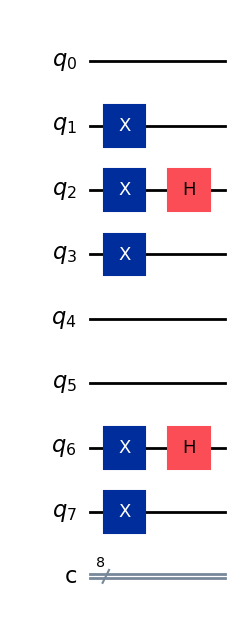

In [ ]:
qc_small = prepare_alice_circuit(abits[:8], abase[:8])
qc_small.draw("mpl")

In [ ]:
def ideal_channel(qc):
    """Placeholder: ideal channel, no modification to the circuit/state."""
    return qc

qc = ideal_channel(qc)

In [ ]:
def add_bob_measurement(qc, bases):
    n = len(bases)
    for i in range(n):
        if bases[i] == 1:
            qc.h(i)
        qc.measure(i, i)
    return qc

bbase = rng.integers(0, 2, N)
qc = add_bob_measurement(qc, bbase)

print("Bob's bases:", bbase, " (0=Z, 1=X)")

Bob's bases: [1 1 1 1 1 1 1 0 0 0 0 1 1 0 0 1 0 1 0 0 1 0 0 0 1 0 1 0 0 1]  (0=Z, 1=X)


In [ ]:
job = backend_sim.run(qc, shots=1)
result = job.result()
counts = result.get_counts()

bitstring = list(counts.keys())[0]
bbits = np.array([int(b) for b in bitstring[::-1]])

print("Bob's measured bits:", bbits)

Bob's measured bits: [0 0 1 1 0 0 1 1 0 0 1 0 1 1 0 1 1 1 0 1 1 1 1 1 1 0 0 1 0 0]


In [ ]:
def sift_key(abits, abase, bbits, bbase):
    matches = abase == bbase
    alice_sifted = abits[matches]
    bob_sifted = bbits[matches]
    return alice_sifted, bob_sifted, matches

alice_sifted, bob_sifted, match_mask = sift_key(abits, abase, bbits, bbase)

comparison_df = pd.DataFrame({
    "Index": range(N),
    "Alice Basis": abase,
    "Bob Basis": bbase,
    "Bases Match": match_mask,
    "Alice Bit": abits,
    "Bob Bit": bbits,
})
comparison_df

,Index,Alice Basis,Bob Basis,Bases Match,Alice Bit,Bob Bit
0,0,0,1,False,0,0
1,1,0,1,False,1,0
2,2,1,1,True,1,1
3,3,0,1,False,1,1
4,4,0,1,False,0,0
5,5,0,1,False,0,0
6,6,1,1,True,1,1
7,7,0,0,True,1,1
8,8,1,0,False,0,0
9,9,0,0,True,0,0


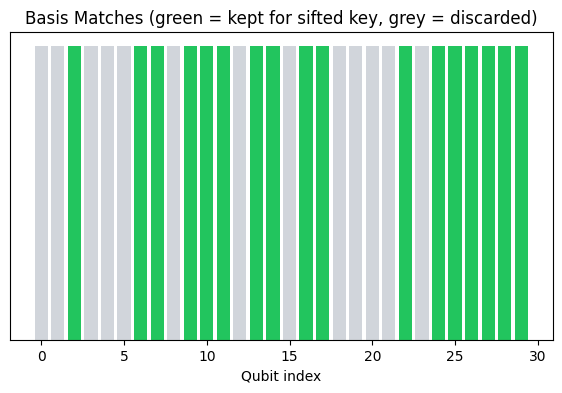

Sifted key (Alice): [1 1 1 0 1 0 1 0 1 1 1 1 0 0 1 0 0]
Sifted key (Bob):   [1 1 1 0 1 0 1 0 1 1 1 1 0 0 1 0 0]
Keys identical (expected, no Eve/noise): True


In [ ]:
colors = ['#22c55e' if m else '#d1d5db' for m in match_mask]
plt.bar(range(N), np.ones(N), color=colors)
plt.yticks([])
plt.xlabel("Qubit index")
plt.title("Basis Matches (green = kept for sifted key, grey = discarded)")
plt.show()

print("Sifted key (Alice):", alice_sifted)
print("Sifted key (Bob):  ", bob_sifted)
print("Keys identical (expected, no Eve/noise):", np.array_equal(alice_sifted, bob_sifted))

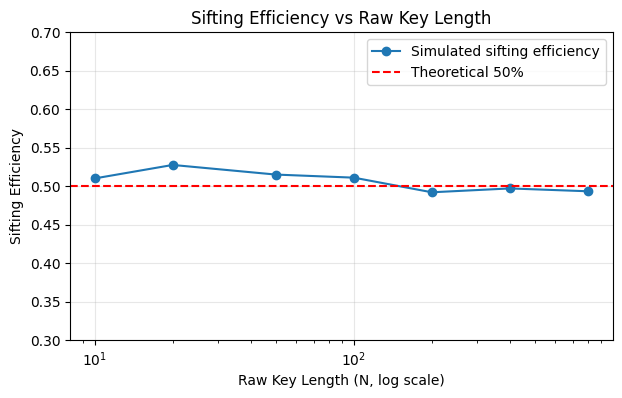

N=  10 -> avg sifting efficiency = 51.00%
N=  20 -> avg sifting efficiency = 52.75%
N=  50 -> avg sifting efficiency = 51.50%
N= 100 -> avg sifting efficiency = 51.10%
N= 200 -> avg sifting efficiency = 49.20%
N= 400 -> avg sifting efficiency = 49.70%
N= 800 -> avg sifting efficiency = 49.33%


In [ ]:
def run_single_trial(n, seed=None):
    abits, abase = generate_random_bits_and_bases(n, seed=seed)
    qc = prepare_alice_circuit(abits, abase)
    qc = ideal_channel(qc)

    bbase_local = np.random.default_rng(seed + 999 if seed is not None else None).integers(0, 2, n)
    qc = add_bob_measurement(qc, bbase_local)

    job = backend_sim.run(qc, shots=1)
    counts = job.result().get_counts()
    bitstring = list(counts.keys())[0]
    bbits_local = np.array([int(b) for b in bitstring[::-1]])

    a_sift, b_sift, mask = sift_key(abits, abase, bbits_local, bbase_local)
    efficiency = np.sum(mask) / n
    return efficiency, len(a_sift), n

# %%
trial_sizes = [10, 20, 50, 100, 200, 400, 800]
avg_efficiencies = []
n_trials_per_size = 20

for size in trial_sizes:
    effs = [run_single_trial(size, seed=i)[0] for i in range(n_trials_per_size)]
    avg_efficiencies.append(np.mean(effs))

# %%
plt.plot(trial_sizes, avg_efficiencies, marker='o', label="Simulated sifting efficiency")
plt.axhline(0.5, color='red', linestyle='--', label="Theoretical 50%")
plt.xscale("log")
plt.xlabel("Raw Key Length (N, log scale)")
plt.ylabel("Sifting Efficiency")
plt.title("Sifting Efficiency vs Raw Key Length")
plt.ylim(0.3, 0.7)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

for size, eff in zip(trial_sizes, avg_efficiencies):
    print(f"N={size:4d} -> avg sifting efficiency = {eff:.2%}")

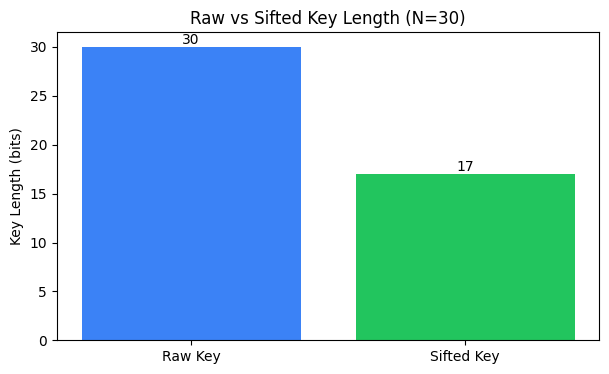

Raw key length: 30
Sifted key length: 17
This run's sifting efficiency: 56.67%


In [17]:
raw_len = N
sifted_len = len(alice_sifted)

plt.bar(["Raw Key", "Sifted Key"], [raw_len, sifted_len], color=["#3b82f6", "#22c55e"])
plt.ylabel("Key Length (bits)")
plt.title(f"Raw vs Sifted Key Length (N={N})")
for i, v in enumerate([raw_len, sifted_len]):
    plt.text(i, v + 0.3, str(v), ha='center')
plt.show()

print(f"Raw key length: {raw_len}")
print(f"Sifted key length: {sifted_len}")
print(f"This run's sifting efficiency: {sifted_len/raw_len:.2%}")